In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import requests
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt


import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import random

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### Open full monster stat csv

In [2]:
mon_data= pd.read_csv('../build data/monster_data_short.csv').dropna(how='all')
mon_data.head(3)

,name,Rarity,Alignment,Creature Level,Trait 1,Trait 2,Trait 3,Trait 4,Trait 5,Trait 6,...,dmg_Bleed,dmg_Lawful,dmg_Chaotic,dmg_Good,dmg_Evil,dmg_Magical,Reaction 1,Reaction 2,Reaction 3,Attack Op
0,ABANDONED ZEALOT,Common,Chaotic Evil,6,Incorporeal,Spirit,Undead,NaN,NaN,NaN,...,False,False,False,False,False,True,"Elegy of the Faithless (abjuration, magical tr...",NaN,NaN,False
1,ADLET,Common,Chaotic Neutral,10,Cold,Humanoid,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,Avenging Bite Trigger A creature within reach ...,NaN,NaN,False
2,ARBITER,Common,Neutral,1,Aeon,Inevitable,Monitor,NaN,NaN,NaN,...,False,True,False,False,False,True,NaN,NaN,NaN,False


In [3]:
#make all monster names lowercase
mon_data['name'] = mon_data['name'].str.lower()

### Clean and organize columns and dataset from raw monster data

In [4]:
col_list= mon_data.columns.to_list()
attack_col = [x for x in col_list if 'attack' in x.lower()]
spell_col = [x for x in col_list if 'spell' in x.lower() or 'spatk' in x.lower()]
move_col= [x for x in col_list if 'speed' in x.lower()]
trait_col= [x for x in col_list if 'trait' in x.lower()]

#make all monster names lowercase
mon_data['name'] = mon_data['name'].str.lower()

stat_col = ['Creature Level', 
 'Perception',
 'HP',
 'AC',
 'Fort',
 'Ref',
 'Will',
 'Fort DC',
 'Ref DC',
 'Will DC']

In [5]:
damage_type_list=['bludgeoning', 
                  'piercing', 
                  'slashing', 
                  'bleed', 
                  'acid', 
                  'cold', 
                  'electricity', 
                  'fire', 
                  'sonic',  
                  'force', 
                  'chaotic', 
                  'evil', 
                  'good', 
                  'lawful', 
                  'spirit',
                  'vitality', 
                  'void', 
                  'mental', 
                  'precision', 
                 'varies']

attack_category_list= ['melee', 'range', 'ranged']

other_mechanic_list = ['reload']

def find_damage_die(attack_text):
    pattern = r"(\d+)d(\d+)([+\-]\d+)"
    pattern_1 = r"(\d+)d(\d+)$"
    #set defaults 
    num_dice=0
    dmg_dice=0
    dmg_mod=0
    
    #save it to a final list for duplicated
    dmg_dice_list=[]
    
    #check if there is damage description in the text and then pull out the damage information 
    if 'damage' in attack_text.lower():
        for text in attack_text.split():
            match = re.match(pattern, text)
            if match:
                num_dice= match.group(1)
                #print(num_dice)
                dmg_dice= match.group(2)
                #print(dmg_dice)
                dmg_mod= match.group(3).replace('+', '')
                #print(dmg_mod)
                dmg_dice_list.append([num_dice, dmg_dice, dmg_mod])
    
            #check for a second match
            match = re.match(pattern_1, text)
            if match:
                num_dice= match.group(1)
                #print(num_dice)
                dmg_dice= match.group(2)
                #print(dmg_dice)
                dmg_mod= 0
                #print(dmg_mod)
                dmg_dice_list.append([num_dice, dmg_dice, dmg_mod])
    return dmg_dice_list

def get_attack_info(series, attack_col):
    mon_choice = series
    attack_info_list= []
    ### pull out the necessary filters from the attack descriptions 
    for col_num, col_value in enumerate(attack_col):
        attack_text = mon_choice[attack_col[col_num]]
        #check if the text is actually a number- then skip
        if attack_text!='0' and attack_text is not None and attack_text!='nan' and isinstance(attack_text, str):
            #print(f"{col_value}:", attack_text)
            #attack name: assuming it is always second 
            attack_name= attack_text.split()[1]
            #print('attack name', attack_name)
            
            #check damage type list for the type
            damage_type = set([x if x in attack_text.lower() else 0 for x in damage_type_list])
            damage_type.discard(0) #remove the filler 
            damage_type= list(damage_type) #convert set to list for easier processing
            #print('damage', damage_type)
            
            #attack category from the list
            attack_cat = attack_category_list[[x in attack_text.lower() for x in attack_category_list].index(True)]
            
            #set default for range and action cost
            action_cost=1
            range_ft=5
            
            #add extra information if the attack is a ranged attack
            if attack_cat == 'range':
                #Find the range attack value
                match = re.search(r"(\d+) feet", attack_text)
                if match:
                    range_ft = match.group(1)

                #Account for any text that is in 'ft'
                match = re.search(r"(\d+) ft", attack_text)
                if match:
                    range_ft = match.group(1)
            
                #check if it needs reload 
                if 'reload' in attack_text:
                    #add it as an extra cost for the action if it includes reload
                    action_cost+=1
            #print(range_ft, action_cost)
            #print('category', attack_cat)
            
            #damage calculations 
            dmg_dice_list = find_damage_die(attack_text)
            #print(f'{num_dice}d{dmg_dice} {dmg_mod}')
            
            #attack modifier is stored in the next column 
            attack_mod=mon_choice[attack_col[col_num+1]]
            #print('attack modifier', attack_mod)
        
            #save information to dictionary 
            attack_info = {'monster_name': mon_choice['name'], 
                           'monster_level': mon_choice['Creature Level'],
                           'attack_number': col_value,
                           'name' :attack_name, 
                           'damage type': damage_type, 
                           'attack_range': range_ft,
                           'action_cost': action_cost,
                           'category': attack_cat, 
                           'dmg_dice_formula': dmg_dice_list, 
                           'attack_roll_mod': attack_mod}
            attack_info_list.append(list(attack_info.values()))
    return attack_info_list

## Filter out other attack information
* Also need to update range and cooldown informaiton, and any status effect to attack

## Pull out information for all attacks 

In [6]:
#Iterate between each monster row and pull out information for physical attacks

all_mon_attack_list= []
for mon_num in range(len(mon_data)):
    #pull out series for specific monster of interest
    mon_choice = mon_data.iloc[mon_num]
    #Run through function to analyze physcial attack actions
    physical_attack_list= get_attack_info(mon_choice, attack_col)

    #save the processes data to a list of lists
    all_mon_attack_list.extend(physical_attack_list)

len(all_mon_attack_list)

5228

### Create a dataframe with each attack action from the attack list analysis

In [7]:
## setup final dataframe 
df_col_name= ['monster_name', 'monster_level', 
              'action_term', 'action_name', 'damage_type', 'attack_range', 'action_cost', 'attack_type', 'damage_dice_calculations', 'attack_roll_mod']

monster_action_list= pd.DataFrame(all_mon_attack_list, columns=df_col_name)

#drop any attack that do not have an attack_roll_mod number to clean up incorrect errors
monster_action_list= monster_action_list.dropna(subset=['attack_roll_mod'])

#drop any attacks that do not have a damage dice calculation
monster_action_list= monster_action_list[(monster_action_list['damage_dice_calculations'].str.len()!=0)]

#view final action dataframe
monster_action_list

#Save the final action dataframe to the data folder 
monster_action_list.to_csv('../build data/all_monster_attack_list.csv')

## Visualize the distribution of monster levels with actions 

array([[<Axes: title={'center': 'monster_level'}>]], dtype=object)

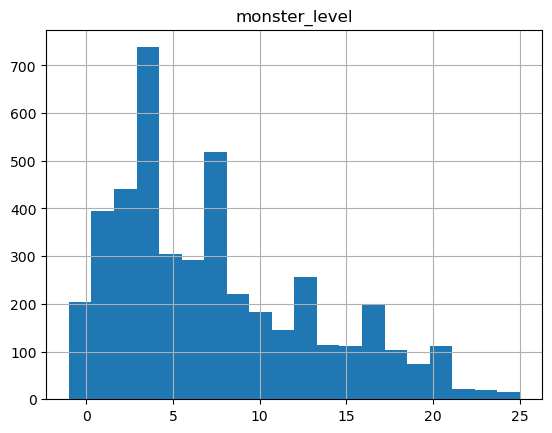

In [8]:
monster_action_list.hist('monster_level', bins=20)

## Visualize the total number of actions per monster

(array([653., 822., 422., 177.,  18.,  10.,   1.,   2.,   1.,   1.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

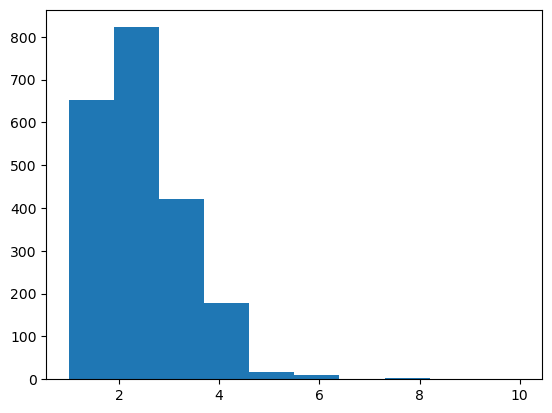

In [9]:
plt.hist(monster_action_list.groupby('monster_name')['action_name'].count().sort_values(ascending=False), bins=10)

## Check for possible data errors 

### All ranged attacks should have an attack range larger than 5ft

In [10]:
monster_action_list[monster_action_list['attack_type']=='range']['attack_range'].value_counts()

attack_range
60     175
10     152
30     149
20     142
120    104
100     68
50      38
5       27
80      14
40      10
200      7
15       4
150      3
90       3
300      2
70       1
75       1
500      1
180      1
5        1
Name: count, dtype: int64

In [11]:
monster_action_list[(monster_action_list['attack_type']=='range') & (monster_action_list['attack_range'] == 5)]

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod
126,arboreal reaper,7,Attack 3,thorns,"[piercing, bleed]",5,1,range,"[[2, 8, 5], [1, 4, 0]]",16.0
246,flaming skull,2,Attack 2,spitfire,[fire],5,1,range,"[[1, 12, 2]]",10.0
617,dragon's blood puffball,8,Attack 1,bloom,[bludgeoning],5,1,range,"[[2, 10, 8], [1, 6, 0]]",18.0
1500,gliminal,9,Attack 2,radiant,[],5,1,range,"[[4, 8, 0]]",19.0
1633,blood hag,8,Attack 3,firebolt,[fire],5,1,range,"[[2, 10, 8]]",19.0
2090,grunka,-1,Attack 3,lesser,[fire],5,1,range,"[[1, 8, 0]]",8.0
2099,mercenary,-1,Attack 4,crossbow,[piercing],5,1,range,"[[1, 8, 0]]",4.0
2110,pelmo,-1,Attack 3,lesser,[fire],5,1,range,"[[1, 8, 0]]",8.0
2192,cheel,1,Attack 2,lesser,[fire],5,1,range,"[[1, 8, 0]]",9.0
2210,experienced mercenary,1,Attack 4,crossbow,[piercing],5,1,range,"[[1, 8, 0]]",5.0


In [12]:
print(mon_data[mon_data['name'] == 'vigilant guard']['Attack 2'])

1086    Ranged longsword +10 (versatile P), Damage 1d8...
Name: Attack 2, dtype: object


There are atleast 28 incorrectly text-processed range attacks 

In [13]:
monster_action_list[monster_action_list['monster_name'] == 'guard']

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod
2091,guard,-1,Attack 1,spear,[piercing],5,1,melee,"[[1, 6, 2]]",6.0
2092,guard,-1,Attack 2,spear,[piercing],20,1,range,"[[1, 6, 2]]",6.0
2218,guard,1,Attack 1,club,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
2219,guard,1,Attack 2,sap,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
2220,guard,1,Attack 3,crossbow,[piercing],120,2,range,"[[1, 8, 0]]",7.0
2221,guard,1,Attack 4,club,[bludgeoning],10,1,range,"[[1, 6, 4]]",7.0
3782,guard,1,Attack 1,club,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
3783,guard,1,Attack 2,sap,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
3784,guard,1,Attack 3,crossbow,[piercing],120,2,range,"[[1, 8, 0]]",7.0
3785,guard,1,Attack 4,club,[bludgeoning],10,1,range,"[[1, 6, 4]]",7.0


----

### open all spell information data csv sheet

In [14]:
# spell_data= pd.read_csv('../raw data/spell_list.csv').dropna(how='all').dropna(axis=1, how='all')
# spell_data.head(3)

In [15]:
spell_data= pd.read_csv('../raw data/spells_spreadsheet.csv') #.dropna(how='all').dropna(axis=1, how='all')
spell_data.head(3)

,Name,Type,Level,Traits,Tradition,Deities,Bloodlines,Casting Time,Components,Range,...,Success,Failure,Critical Failure,Heightening,Heal,Damage,Counteract,Conditions,Source,Nethys Link
0,Acid Splash,Cantrip,1,"Acid,Attack,Cantrip,Evocation","arcane,primal",NaN,demonic,Two Actions,"somatic,verbal",30 feet,...,NaN,NaN,NaN,Heightened (3rd) The initial damage increases ...,False,True,False,NaN,Core Rulebook pg. 316,http://2e.aonprd.com/Spells.aspx?ID=3
1,Approximate,Cantrip,1,"Cantrip,Detection,Divination","arcane,divine,occult,primal",NaN,NaN,Two Actions,"somatic,verbal",10 feet,...,NaN,NaN,NaN,NaN,False,False,False,NaN,Secrets of Magic pg. 90,http://2e.aonprd.com/Spells.aspx?ID=864
2,Bullhorn,Cantrip,1,"Auditory,Cantrip,Illusion","arcane,divine,occult",NaN,NaN,Two Actions,"somatic,verbal",NaN,...,NaN,NaN,NaN,Heightened (5th) Your voice can be heard clear...,False,False,False,NaN,Secrets of Magic pg. 93,http://2e.aonprd.com/Spells.aspx?ID=877


### pull out list of all spell names to use as a reference for spell actions

In [16]:
all_spell_list = spell_data['Name'].unique().tolist()
all_spell_list= [x.lower() for x in all_spell_list]
len(all_spell_list)

1050

### Prepare and clean up spell data spreadsheet to make for easier merging later

In [17]:
#Make all of the names and columns lowercase
spell_data.columns= spell_data.columns.str.lower()

spell_data['name']= spell_data['name'].str.lower()
spell_data['casting time']= spell_data['casting time'].str.lower()

#add a column that indicates if the spell costs an action to cast(1), or if the cast is in time (0)
spell_data['action_cost'] = [True if 'action' or 'actions' in x else False for x in spell_data['casting time']]

#manually adjust the action cost using a dictionary of avaiable terms 
cast_time_dict = {'two actions': 2, 
 'single action': 1,
 'three actions':3,
 'reaction':0,
 'single action to three actions': 1,
 'two actions or three actions':2,
 'single action or two actions':1,
 'free action':0,
       'single action to two actions':1}

spell_data['casting time']= spell_data['casting time'].replace(cast_time_dict)

#fill all nan values with 0 
spell_data= spell_data.fillna(0)

#view cleanned dataframe
spell_data.head(3)

,name,type,level,traits,tradition,deities,bloodlines,casting time,components,range,...,failure,critical failure,heightening,heal,damage,counteract,conditions,source,nethys link,action_cost
0,acid splash,Cantrip,1,"Acid,Attack,Cantrip,Evocation","arcane,primal",0,demonic,2,"somatic,verbal",30 feet,...,0,0,Heightened (3rd) The initial damage increases ...,False,True,False,0,Core Rulebook pg. 316,http://2e.aonprd.com/Spells.aspx?ID=3,True
1,approximate,Cantrip,1,"Cantrip,Detection,Divination","arcane,divine,occult,primal",0,0,2,"somatic,verbal",10 feet,...,0,0,0,False,False,False,0,Secrets of Magic pg. 90,http://2e.aonprd.com/Spells.aspx?ID=864,True
2,bullhorn,Cantrip,1,"Auditory,Cantrip,Illusion","arcane,divine,occult",0,0,2,"somatic,verbal",0,...,0,0,Heightened (5th) Your voice can be heard clear...,False,False,False,0,Secrets of Magic pg. 93,http://2e.aonprd.com/Spells.aspx?ID=877,True


In [18]:
def return_only_num(text):
    match = re.findall(r'\d+', text)
    if match:
        num_list = list(set(match))
    else:
        num_list=[]
    return num_list

### Iterate cleanup across all spells on the datasheet

In [19]:
#save output lists to make into a new column at the end
add_spell_info=[]
all_damage_die_list=[]

#apply the cleanup code to every row on the spell list 
for row in range(len(spell_data)):
    one_spell= spell_data.iloc[row]

    ## update the action cost column to have the correct number 
    if one_spell['action_cost']==True:
            one_spell['action_cost'] = one_spell['casting time']
    
    #Update columns with only number information 
    one_spell['target'] = return_only_num(str(one_spell['target']))
    one_spell['range'] = return_only_num(str(one_spell['range']))
    
    # #If it is a spell attack, record the damage from description
    # one_spell['damage']
    damage_dice_calc=[]
    if one_spell['spell attack'] == True and one_spell['damage'] == True:
        spell_info = one_spell['effect']
        damage_dice_calc = find_damage_die(spell_info)
    all_damage_die_list.append(damage_dice_calc)
    
    #check spell description and add important information to a catch-all column
    spell_descriptors = []
    match= re.search(r"attack", spell_info)
    if match:
        if 'ranged.*?attack' or 'ranged' in spell_info:
            spell_descriptors.append('ranged')
        
        if 'melee.*?attack' or 'melee' in spell_info:
            spell_descriptors.append('melee')
            
        if 'cone' or 'area' in spell_info:
            spell_descriptors.append('area')
        
        if 'spell attack roll' in spell_info:
            spell_descriptors.append('spell attack roll')
    
    match= re.findall(r"plus.*?spellcasting ability modifier", spell_info)
    if match:
        spell_descriptors.append('add spellcasting modifier')

    #add collected extra data to the main dataframe
    add_spell_info.append(spell_descriptors)

    #rewrite the main dataframe with the updated clean series 
    spell_data.iloc[row] = one_spell


#at the end, add the two new columns to the dataframe 
spell_data['damage_calculation']= all_damage_die_list
spell_data['spell_features']= add_spell_info

#save cleaned data frame to data folder 
#Save the final action dataframe to the data folder 
spell_data.to_csv('../build data/cleaned_spell_list.csv')

#view final dataframe 
spell_data

,name,type,level,traits,tradition,deities,bloodlines,casting time,components,range,...,heightening,heal,damage,counteract,conditions,source,nethys link,action_cost,damage_calculation,spell_features
0,acid splash,Cantrip,1,"Acid,Attack,Cantrip,Evocation","arcane,primal",0,demonic,2,"somatic,verbal",[30],...,Heightened (3rd) The initial damage increases ...,False,True,False,0,Core Rulebook pg. 316,http://2e.aonprd.com/Spells.aspx?ID=3,2,"[[1, 6, 0]]","[ranged, melee, area]"
1,approximate,Cantrip,1,"Cantrip,Detection,Divination","arcane,divine,occult,primal",0,0,2,"somatic,verbal",[10],...,0,False,False,False,0,Secrets of Magic pg. 90,http://2e.aonprd.com/Spells.aspx?ID=864,2,[],"[ranged, melee, area]"
2,bullhorn,Cantrip,1,"Auditory,Cantrip,Illusion","arcane,divine,occult",0,0,2,"somatic,verbal",[0],...,Heightened (5th) Your voice can be heard clear...,False,False,False,0,Secrets of Magic pg. 93,http://2e.aonprd.com/Spells.aspx?ID=877,2,[],"[ranged, melee, area]"
3,chill touch,Cantrip,1,"Cantrip,Necromancy,Negative","arcane,divine,occult",0,"undead,shadow",2,"somatic,verbal",[],...,Heightened (+1) The negative damage to living ...,False,True,False,"Enfeebled,Fleeing",Core Rulebook pg. 323,http://2e.aonprd.com/Spells.aspx?ID=35,2,[],"[ranged, melee, area]"
4,dancing lights,Cantrip,1,"Cantrip,Evocation,Light","arcane,occult,primal",0,0,2,"somatic,verbal",[120],...,0,False,False,False,0,Core Rulebook pg. 327,http://2e.aonprd.com/Spells.aspx?ID=58,2,[],"[ranged, melee, area]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,apex companion,Focus,10,"Uncommon,Druid,Polymorph,Transmutation",0,0,0,2,"somatic,verbal",[30],...,0,True,True,False,0,Pathfinder #150: Broken Promises pg. 77,http://2e.aonprd.com/Spells.aspx?ID=562,2,[],"[ranged, melee, area, spell attack roll]"
1046,fatal aria,Focus,10,"Uncommon,Bard,Composition,Death,Emotion,Enchan...",0,0,0,1,verbal,[30],...,0,False,True,False,Dying,Core Rulebook pg. 386,http://2e.aonprd.com/Spells.aspx?ID=383,1,[],"[ranged, melee, area, spell attack roll]"
1047,heros defiance,Focus,10,"Uncommon,Champion,Healing,Necromancy,Positive",0,0,0,0,verbal,[0],...,0,False,True,False,"Dying,Unconscious",Core Rulebook pg. 387,http://2e.aonprd.com/Spells.aspx?ID=394,0,[],"[ranged, melee, area, spell attack roll]"
1048,pied piping,Focus,10,"Uncommon,Bard,Composition,Enchantment,Incapaci...",0,0,0,2,verbal,[0],...,0,False,False,False,"Hostile,Controlled",Advanced Players Guide pg. 228,http://2e.aonprd.com/Spells.aspx?ID=730,2,[],"[ranged, melee, area, spell attack roll]"


-----

## Pull out spell attack information from monster list

In [20]:
# ## pull out the magical monster list 
# mon_num = mon_data[mon_data['SPAtk 1'].notna()].iloc[50].name
# mon_choice = mon_data.iloc[mon_num] #459
# mon_choice

In [21]:
def clean_text_spell_name(text):
    #remove any of the number or special characters from the word 
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    #remove a list of extra words
    prohibited_words = ['cantrips', 'cantrip', 'th ', 'st ', 'nd ', 'rd ', '(at will)']
    for word in prohibited_words:
        text = text.replace(word, '')
    
    #remove any trailing white space
    clean_word = text.strip()
    return clean_word

### Pull out spell name actions from monster spell column descriptions
* Issues - 'innate' spells not processing correctly - skipped over instead of included despite being part of the approved spell list types

In [22]:
#create a new list to save all processed information to 
spell_attack_action=[]

#define global veriable information 
#define categorical filters
spell_types= ['innate', 'prepared', 'focus']

#iterate between all monsters on the monster list that do have spell attacks
for mon_num in range(len(mon_data)):
    #pull out series for specific monster of interest
    mon_choice = mon_data.iloc[mon_num]
    #check if the monster has any spells or spell attacks
    if mon_choice['Spells 1']!='0':
        #Define the creature information to be included in the final dataframe 
        creature_info = [mon_choice['name'], mon_choice['Creature Level']]
        
        #iterate across all spell-type columns and only process columns with text information 
        for col_idx, col_title in enumerate(spell_col):
            col_content= mon_choice[col_title]
            if col_content!='0' and col_content is not None and col_content!='nan' and isinstance(col_content, str):
                spell_text= col_content
                
                #pull out the spell category from the start of the monster stat line 
                spell_cat = set([x if x in spell_text.lower() else 0 for x in spell_types])
                spell_cat.discard(0) #remove the filler 
                spell_cat= list(spell_cat) #convert set to list for easier processing
                
                #Identify spell stats
                #define default values 
                spell_dc= []
                spell_attack=[]
                
                match = re.search(r"dc\s*(\d+)" , spell_text.lower())
                if match:
                    spell_dc = match.group(1)
                    #print('dc', spell_dc)
                
                #identify spell attack modifier
                match = re.search(r"attack\s*([+/-]\d+)" , spell_text)
                if match:
                    spell_attack = match.group(1)
                    #print('attack_mod', spell_attack)
                
                ## Save group information for all these spells 
                group_spell_info= [col_title, spell_cat, spell_dc, spell_attack]
                
                #iterate and pull out the spell options from the list 
                for spell_group in spell_text.split(';'):
                    check_spell= spell_group.strip() 
                    #print('check_spell', check_spell)
                    match= re.search(r"^(\d+)", check_spell) #check if the spell starts with the level category
                    if match:
                        spell_slot_level = match.group(1)
                        #print('spell slot', spell_slot_level)
                
                    #pull out spell names specifically 
                    for word in spell_group.split(','):
                        #pull out the cleaned spell name 
                        clean_word = clean_text_spell_name(word)
                        #print('spell word', clean_word)
                        if clean_word.strip().lower() in all_spell_list: #Check if the spells are included in our spell dataset
                            spell_name = clean_word
                            spell_attack_action.append(creature_info + group_spell_info + [spell_slot_level, spell_name])


#Convert the analyzed spell attack list info a dataframe
df_spell_col= ['monster_name', 'monster_level', 'spell column', 'spell type', 'spell_DC', 'spell_attack_mod', 'spell_slot_level', 'spell_name']
monster_spell_attack_actionlist = pd.DataFrame(spell_attack_action, columns=df_spell_col)

#view a sample of the spell actionlist dataframe
monster_spell_attack_actionlist.sample(10)

,monster_name,monster_level,spell column,spell type,spell_DC,spell_attack_mod,spell_slot_level,spell_name
1190,adult forest dragon,14,Spells 2,[prepared],34,+28,4,solid fog
693,doru,1,Spells 1,[innate],17,[],1,charm
1405,young silver dragon,10,Spells 2,[prepared],28,+23,4,read omens
2121,kraken,18,Spells 1,[innate],40,[],8,punishing winds
4181,mother venom,17,Spells 1,[],39,+30,2,spider climb
5719,eremite,20,Spells 1,[innate],42,[],9,blade barrier
3089,onyx alliance agent,6,Spells 1,[],24,+16,1,sanctuary
32,bythos,16,Spells 1,[innate],37,[],7,dimensional lock
3432,khurfel,10,Spells 1,[innate],28,+20,3,paralyze
2458,carlessa,3,Spells 1,[prepared],20,+12,1,summon animal


## Merge monster action list with the spell informaiton dataframe to have all spell data

In [23]:
mon_spell_info_actions = pd.merge(monster_spell_attack_actionlist, 
                                  spell_data, 
                                  left_on='spell_name', 
                                  right_on='name', 
                                  how='left').drop(columns='name')

##Save the processed dataframe to the project drive 
#Save the final action dataframe to the data folder 
mon_spell_info_actions.to_csv('../build data/all_monster_spell_actionlist.csv')

#view a random sample 
mon_spell_info_actions.sample(5)

,monster_name,monster_level,spell column,spell type,spell_DC,spell_attack_mod,spell_slot_level,spell_name,type,level,...,heightening,heal,damage,counteract,conditions,source,nethys link,action_cost,damage_calculation,spell_features
5845,adult silver dragon,14,Spells 2,[prepared],33,+29,4,restoration,Spell,2.0,...,Heightened (4th) Add drained to the list of co...,False,False,False,"Clumsy,Enfeebled,Stupefied",Core Rulebook pg. 364,http://2e.aonprd.com/Spells.aspx?ID=258,1 minute,[],"[ranged, melee, area]"
3966,king harral,14,Spells 1,[prepared],35,+27,1,electric arc,Cantrip,1.0,...,Heightened (+1) The damage increases by 1d4,False,True,False,0,Core Rulebook pg. 335,http://2e.aonprd.com/Spells.aspx?ID=97,2,[],"[ranged, melee, area, spell attack roll]"
3169,nevashi,7,Spells 1,[],25,+17,1,detect magic,Cantrip,1.0,...,Heightened (3rd) You learn the school of magic...,False,False,False,0,Core Rulebook pg. 328,http://2e.aonprd.com/Spells.aspx?ID=66,2,[],"[ranged, melee, area]"
5441,simurgh,18,Spells 1,[innate],42,[],9,flame strike,Spell,5.0,...,Heightened (+1) The damage increases by 2d6,False,True,False,0,Core Rulebook pg. 338,http://2e.aonprd.com/Spells.aspx?ID=120,2,[],"[ranged, melee, area, spell attack roll]"
2952,voz lirayne,5,Spells 1,[prepared],23,+15,1,light,Cantrip,1.0,...,Heightened (4th) The object sheds bright light...,False,False,False,0,Core Rulebook pg. 348,http://2e.aonprd.com/Spells.aspx?ID=171,2,[],"[ranged, melee, area, spell attack roll, add s..."


-----

### Standardize the monster attack format and merge the spell attacks with the physical attacks 

In [24]:
monster_action_list.head(3)

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod
0,abandoned zealot,6,Attack 1,hand,[],5,1,melee,"[[2, 10, 4]]",16.0
1,adlet,10,Attack 1,spear,"[cold, piercing]",5,1,melee,"[[2, 6, 9], [1, 6, 0]]",20.0
2,adlet,10,Attack 2,jaws,"[cold, slashing]",5,1,melee,"[[2, 8, 9], [1, 6, 0]]",19.0


In [25]:
convert_col_names = {'spell column': 'action_term', 
                     'spell_name':'action_name', 
                     'range': 'attack_range', 
                     'type':'attack_type', 
                     'damage_calculation': 'damage_dice_calculations', 
                     'spell_attack_mod':'attack_roll_mod'}

In [26]:
short_spell_col = ['monster_name', 
 'monster_level', 
 'spell column', 
 'spell_name', 
 'spell_DC', 
 'spell_attack_mod', 
 'spell_slot_level', 
 'type', 
 'casting time', 
 'range', 
 'target', 
 'area', 
 'duration',
 'saving throw', 
 'spell attack', 
 'conditions', 
 'action_cost']

In [27]:
#shorten the dataframe to include just the relevant columns 
spell_actionlist = mon_spell_info_actions[short_spell_col]

#rename the columns that match with the physical attack list 
spell_actionlist = spell_actionlist.rename(columns=convert_col_names)

spell_actionlist.head(3)

,monster_name,monster_level,action_term,action_name,spell_DC,attack_roll_mod,spell_slot_level,attack_type,casting time,attack_range,target,area,duration,saving throw,spell attack,conditions,action_cost
0,abandoned zealot,6,Spells 1,crisis of faith,24,[],4,Spell,2,[30],[1],0,0,Will,False,0,2
1,arbiter,1,Spells 1,read omens,17,[],4,Spell,10 minutes,[0],[0],0,0,0,False,0,10 minutes
2,arbiter,1,Spells 1,command,17,[],1,Spell,2,[30],[1],0,until the end of the targets next turn,Will,False,"Fleeing,Prone",2


## merge physical and spell attacklist to one major action list 

In [31]:
all_actionlist = pd.concat([monster_action_list, spell_actionlist]).fillna(0)

#save all action list to the data folder 
all_actionlist.to_csv('../build data/monster_all_actionlist.csv')

all_actionlist.sample(10)

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod,spell_DC,spell_slot_level,casting time,target,area,duration,saving throw,spell attack,conditions
5289,maharaja,20,Spells 1,modify memory,0,[30],2,Spell,0,[],47,4,2,[1],0,unlimited,Will,False,0
1998,grioth cultist,3,Spells 1,stabilize,0,[30],2,Cantrip,0,+12,20,1,2,[1],0,0,0,False,"Dying,Unconscious"
5248,dandasuka,5,Spells 1,ventriloquism,0,[0],2,Spell,0,+15,22,1,2,[0],0,10 minutes,0,False,0
677,pit fiend (tyrant devil),20,Spells 1,scrying,0,[],10 minutes,Spell,0,[],42,8,10 minutes,[1],0,sustained up to 10 minutes,Will,False,0
1490,adult bronze dragon,13,Spells 2,read aura,0,[30],1 minute,Cantrip,0,+27,33,1,1 minute,[1],0,0,0,False,0
4682,chronicler,3,Spells 1,flaming sphere,0,[30],2,Spell,0,+12,20,2,2,[0],1 5-foot square,sustained up to 1 minute,Reflex,False,0
1287,fetchling scout,1,Attack 2,dagger,[piercing],10,1,range,"[[1, 4, 1]]",9.0,0,0,0,0,0,0,0,0,0
5215,thulgant,18,Spells 1,detect magic,0,[0],2,Cantrip,0,[],40,7,2,[0],30-foot emanation,0,0,False,0
3579,tempest-sun mage,11,Spells 1,chain lightning,0,[500],2,Spell,0,+20,30,6,2,[1],0,0,Reflex,False,0
4161,naunet,7,Attack 2,tail,"[bludgeoning, chaotic]",5,1,melee,"[[2, 8, 8], [1, 6, 0]]",18.0,0,0,0,0,0,0,0,0,0


----

#### Simplify monster stats -- speed, base skills, and traits

In [34]:
mon_data.head(3)

,name,Rarity,Alignment,Creature Level,Trait 1,Trait 2,Trait 3,Trait 4,Trait 5,Trait 6,...,dmg_Bleed,dmg_Lawful,dmg_Chaotic,dmg_Good,dmg_Evil,dmg_Magical,Reaction 1,Reaction 2,Reaction 3,Attack Op
0,abandoned zealot,Common,Chaotic Evil,6,Incorporeal,Spirit,Undead,NaN,NaN,NaN,...,False,False,False,False,False,True,"Elegy of the Faithless (abjuration, magical tr...",NaN,NaN,False
1,adlet,Common,Chaotic Neutral,10,Cold,Humanoid,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,Avenging Bite Trigger A creature within reach ...,NaN,NaN,False
2,arbiter,Common,Neutral,1,Aeon,Inevitable,Monitor,NaN,NaN,NaN,...,False,True,False,False,False,True,NaN,NaN,NaN,False


In [38]:
### columns from earlier screening that needs to be condensed from the monster dataset

stat_col
move_col
trait_col

['Trait 1', 'Trait 2', 'Trait 3', 'Trait 4', 'Trait 5', 'Trait 6', 'Trait 7']

In [44]:
stat_col

['Creature Level',
 'Perception',
 'HP',
 'AC',
 'Fort',
 'Ref',
 'Will',
 'Fort DC',
 'Ref DC',
 'Will DC']

In [47]:
# for each monster, pull out all the numbers from the move_col 


mon_data.iloc[100]['Fort DC']

nan

In [43]:
mon_data.iloc[100][trait_col[1]]

nan

-----

## Reformat and clean character actionlist 

In [54]:
def open_clean_actionlist(filepath):
    actionlist = pd.read_csv(filepath)
    #clean up nan calues 
    actionlist= actionlist.replace('x', 0).fillna(0)
    return actionlist

char_actlist = open_clean_actionlist('../build data/rogue_actionlist.csv')
char_actlist.head(3)

,Cost,requirement,action,action type,trait,Description,HP bonus,save effect,AC effect,target ac,...,attack roll,range,number die,damage die,additional damage,damage type,duration (round),cool down (round),crit success,crit failure
0,1,0,move towards target,movement,speed,25ft (5 squares),0,0,0,0,...,0,25,0,0,0,0,0,0,0.0,0.0
1,1,0,move away from target,movement,speed,25ft (5 squares),0,0,0,0,...,0,25,0,0,0,0,0,0,0.0,0.0
2,1,2 characters 1 target,flank target,movement,speed,25ft (5 squares); Target is off-guard (-2 AC),0,0,0,12,...,0,25,0,0,1,0,0,0,0.0,0.0


In [55]:
char_actlist.columns

Index(['Cost', 'requirement', 'action', 'action type', 'trait', 'Description ',
       'HP bonus', 'save effect', 'AC effect', 'target ac ', 'target saves',
       'target effect', 'save roll', 'attack roll', 'range ', 'number die',
       'damage die', 'additional damage', 'damage type', 'duration (round)',
       'cool down (round)', 'crit success', 'crit failure'],
      dtype='object')

In [68]:
loc_change_list =[]
for action in range(len(char_actlist)):
    action_choice = char_actlist.iloc[action]
    if action_choice['action'] == 'move towards target':
        loc_change_list.append('+speed')
    elif action_choice['action'] == 'move away from target':
        loc_change_list.append('-speed')
    elif action_choice['action'] == 'flank target':
        loc_change_list.append('+speed')
    else:
        loc_change_list.append(0)

char_actlist['location_change'] = loc_change_list